# Avenue 1: a methodical, scientific multicollinearity screen for environmental features

**What this notebook is for.** Environmental candidate variables (terrain, wind, climate, soil,
forest-edge position) were added to this project ad hoc, over many sessions, with correlation
only checked *after* fitting a model, as interpretive context. That order is backwards, and a
2026-08-06 `llm-council` review (`documentation/experiment_log.md`) found real problems with the
first draft of a fix. This notebook implements the corrected method and builds this project's
actual feature-set tiers from it.

**Scope.** This screen only ever touches *environmental* variables (terrain/wind/climate/
soil/edge) -- explicitly NOT the stand-metric/management columns (`CanopyCover`, `Thin`,
`time_since_thinning`, etc.) that are already fed into every DNN/PINN model's main network
input regardless of which environmental feature set is chosen
(`models/common/torch_data.py`'s `NUMERIC_SCALED_COLUMNS`/`BINARY_PASSTHROUGH_COLUMNS`). Adding
them again here would just feed the same information through two pathways.

**The staged build-up.** This mirrors how the analysis actually thinks about the evidence:

1. **Stage 1 -- terrain (DTM-derived) only.**
2. **Stage 2 -- terrain + wind.**
3. **Stage 3 -- + whichever "other" categories (climate / soil / forest-edge) show real,
   freshly-measured signal.** Not every remaining category automatically qualifies -- this stage
   filters by evidence, computed here, not by including everything on principle.
4. **Stage 4 -- every environmental category, unfiltered.** This is the "for the sake of
   checking and proof" tier: no category is excluded, even ones that didn't clear stage 3's bar,
   so a wider comparison is always available.

**Two different uses, two different amounts of screening (per the council review).** A neural
network being *fed* raw terrain/wind values (Avenue 1's DNN/PINN `y_max`/`k` conditioning) isn't
hurt by redundant inputs the way a linear model's coefficients or a SHAP/permutation-importance
*interpretation* is -- discarding a correlated variable there only removes real information for
no real benefit. So:

- **DNN/PINN raw feature-set tiers** (`ENV_TERRAIN_FEATURE_SETS` in `models/common/torch_data.py`)
  get **Stage 1 + Stage 2 of the screen only**: drop deterministic duplicates and near-exact
  empirical duplicates (`|rho| >= 0.95`). Nothing with real, distinct variance is removed.
- **The attribution tooling** (`models/xgb_environmental`'s SHAP/permutation/refit-ablation, and
  the `av1_grouped_category_importance.ipynb` notebook) gets the **full screen**, including the
  iterative VIF pass -- because collinearity there directly corrupts *which variable gets the
  credit*, which is the entire point of that tooling.

See `models/xgb_environmental/multicollinearity_screen.py` for the actual implementation and
`documentation/experiment_log.md`'s 2026-08-06 entry for the full council review this design
responds to.

In [1]:
import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from models.xgb_environmental.data import load_plots_for_cohort
from models.xgb_environmental.xgb_environmental import FEATURE_PROVENANCE, ALL_FEATURE_COLUMNS
from models.xgb_environmental.grouped_analysis import CATEGORY_GROUPS
from models.xgb_environmental.multicollinearity_screen import (
    drop_deterministic_duplicates,
    compute_correlation_matrix,
    find_near_exact_duplicates,
    choose_representative_loser,
    run_full_screen,
)
from models.common.torch_data import (
    NUMERIC_SCALED_COLUMNS,
    BINARY_PASSTHROUGH_COLUMNS,
    ENV_TERRAIN_FEATURE_SETS,
)

import pandas as pd
from scipy.stats import spearmanr

pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

## 1. Target-circularity check (the council's "one thing to do first")

Before screening anything, confirm no environmental candidate was already used to *build* the
target it's meant to explain -- otherwise every number downstream is meaningless. This project's
own targets are:

- Avenue 1's own target here: `mean_cr_residual` (used throughout this notebook as the real,
  freshly-computed signal for tie-breaking -- see `models/xgb_environmental/data.py`). Built
  in `models/growth_curve_attribution/scale_comparison_check.py::build_plot_level_table()` as
  `y_max_fit - y_max_yldc`: a per-plot Chapman-Richards fit against that plot's own repeated
  height observations, minus the Forestry Commission's static yield-class table value. Both
  halves come from height/Age survey data and the static yield-class lookup only.
- Avenue 1's DNN/PINN height-prediction target, `elev_percentile_95th`, is raw LiDAR height --
  even more obviously untouched by any environmental variable.

**Check, not assumption:** confirmed directly by reading `build_plot_level_table()` -- its inputs
are `load_filtered_growth_curve_table(cohort)` (height/Age/LiDAR-year columns) and the FC's own
static `y_max_yldc` lookup. No terrain, wind, climate, soil, or edge column appears anywhere in
that function. **Pass -- no circularity.**

In [2]:
plots_df = load_plots_for_cohort("4survey")
print(f"Loaded {len(plots_df):,} plots for the 4survey cohort.")
print("mean_cr_residual present:", "mean_cr_residual" in plots_df.columns)
TARGET_COLUMN = "mean_cr_residual"

# Unordered categorical class IDs -- excluded from every correlation/VIF step below, same
# exclusion torch_data.py already applies (treating these as continuous was a real bug once,
# see the 2026-08-01 LISA-test entry in documentation/experiment_log.md).
CATEGORICAL_COLUMNS = ["ceh_pedotope", "ceh_subsurface_drainage", "ceh_textural_composition"]

Loaded 71,766 plots for the 4survey cohort.
mean_cr_residual present: True


## 2. Define the four cumulative stages

Stage 3's membership isn't decided on principle -- each remaining category (climate, soil, edge
position) is checked here for real signal (max |Spearman rho| of any of its own columns against
`mean_cr_residual`) before being allowed in. Stage 4 skips that filter entirely: every
environmental category, no exceptions, as the "for the sake of proof" comparison tier.

In [3]:
def category_signal_strength(df, category_columns, target_column):
    '''The strongest single-column |Spearman rho| with the target inside one category --
    a quick, fresh, transparent check of whether a category carries any real individual signal
    at all, before deciding whether stage 3 includes it.'''
    best_column, best_rho = None, 0.0
    for column in category_columns:
        if column in CATEGORICAL_COLUMNS:
            continue
        rho, _ = spearmanr(df[column], df[target_column], nan_policy="omit")
        if abs(rho) > best_rho:
            best_column, best_rho = column, abs(rho)
    return best_column, best_rho


STAGE3_SIGNAL_THRESHOLD = 0.10  # a deliberately low bar -- "carries any real individual signal
# at all", not "is a strong predictor on its own". Printed alongside every category's own number
# below so the cutoff's effect on each specific category is visible, not just asserted.

other_categories = ["climate", "soil_site", "spatial_position_edge_effects"]
stage3_extra_categories = []
print(f"{'category':<32}{'strongest column':<28}{'|rho| with target':>18}   included in stage 3?")
for category in other_categories:
    best_column, best_rho = category_signal_strength(plots_df, CATEGORY_GROUPS[category], TARGET_COLUMN)
    included = best_rho >= STAGE3_SIGNAL_THRESHOLD
    if included:
        stage3_extra_categories.append(category)
    print(f"{category:<32}{best_column or '(none)':<28}{best_rho:>18.4f}   {'yes' if included else 'no'}")

print(f"\nStage 3 will add: {stage3_extra_categories}")
if set(stage3_extra_categories) == set(other_categories):
    print(
        "\nNote: every remaining category cleared the signal threshold this run, so stage 3 "
        "and stage 4 end up as the SAME candidate pool below -- that's a genuine result (the "
        "filter simply didn't bind), not a bug. Stage 4 is kept as a separate, explicitly "
        "named tier anyway, since the filter's job is to be a real check every time this is "
        "re-run, not to always produce two different lists."
    )

category                        strongest column             |rho| with target   included in stage 3?
climate                         chelsa_bio12_precip_mm                  0.3639   yes
soil_site                       soilgrids_ph                            0.2709   yes


spatial_position_edge_effects   dist_to_road                            0.3769   yes

Stage 3 will add: ['climate', 'soil_site', 'spatial_position_edge_effects']

Note: every remaining category cleared the signal threshold this run, so stage 3 and stage 4 end up as the SAME candidate pool below -- that's a genuine result (the filter simply didn't bind), not a bug. Stage 4 is kept as a separate, explicitly named tier anyway, since the filter's job is to be a real check every time this is re-run, not to always produce two different lists.


In [4]:
terrain_columns = [c for c in CATEGORY_GROUPS["terrain"] if c not in CATEGORICAL_COLUMNS]
wind_columns = [c for c in CATEGORY_GROUPS["wind"] if c not in CATEGORICAL_COLUMNS]
other_all_columns = {
    category: [c for c in CATEGORY_GROUPS[category] if c not in CATEGORICAL_COLUMNS]
    for category in other_categories
}

STAGE_CANDIDATES = {}
STAGE_CANDIDATES["stage1_terrain"] = list(terrain_columns)
STAGE_CANDIDATES["stage2_terrain_wind"] = STAGE_CANDIDATES["stage1_terrain"] + wind_columns
STAGE_CANDIDATES["stage3_terrain_wind_plus"] = STAGE_CANDIDATES["stage2_terrain_wind"] + [
    column for category in stage3_extra_categories for column in other_all_columns[category]
]
STAGE_CANDIDATES["stage4_all_environmental"] = STAGE_CANDIDATES["stage2_terrain_wind"] + [
    column for category in other_categories for column in other_all_columns[category]
]

for stage_name, columns in STAGE_CANDIDATES.items():
    print(f"{stage_name:<28} {len(columns):>3} raw candidates before screening")

stage1_terrain                14 raw candidates before screening
stage2_terrain_wind           27 raw candidates before screening
stage3_terrain_wind_plus      40 raw candidates before screening
stage4_all_environmental      40 raw candidates before screening


## 3. Stage 1-2 only: the raw DNN/PINN feature-set tiers

Deterministic-duplicate removal, then near-exact empirical duplicates (`|rho| >= 0.95`). No VIF,
no discarding of real variance -- the network sees everything that isn't a literal repeat of
another column already in its own input.

In [5]:
def dedup_only(df, candidate_columns, feature_provenance, target_column, near_exact_threshold=0.95):
    '''Stages 1-2 only: deterministic duplicates, then near-exact empirical duplicates.
    Returns (kept_columns, drop_log_rows) -- no VIF step, on purpose (see the DNN/PINN
    scoping note above).'''
    drop_log_rows = []
    after_stage1, stage1_drops = drop_deterministic_duplicates(candidate_columns)
    drop_log_rows.extend(stage1_drops)

    correlation_matrix = compute_correlation_matrix(df, after_stage1)
    near_exact_pairs = find_near_exact_duplicates(correlation_matrix, threshold=near_exact_threshold)
    kept = list(after_stage1)
    for column_a, column_b, rho in near_exact_pairs:
        if column_a not in kept or column_b not in kept:
            continue
        losers = choose_representative_loser([column_a, column_b], feature_provenance, df, target_column)
        for loser in losers:
            kept.remove(loser)
            drop_log_rows.append({"column": loser, "stage": "2_near_exact_duplicate", "reason": f"rho={rho:.3f} with its kept partner"})
    return kept, pd.DataFrame(drop_log_rows)


DNN_PINN_TIERS = {}
for stage_name, candidates in STAGE_CANDIDATES.items():
    kept, drop_log = dedup_only(plots_df, candidates, FEATURE_PROVENANCE, TARGET_COLUMN)
    # tas_mean/groundfrost_mean are COHORT-SPECIFIC columns in the raw environmental export
    # (tas_mean_4survey/tas_mean_6survey) -- load_plots_for_cohort() resolves that suffix for
    # THIS notebook and for xgb_environmental's own pipeline, but
    # models/common/torch_data.py::load_split_table_with_terrain() does NOT do that resolution
    # (a real, documented, unfixed gap -- see torch_data.py's own comment on why
    # `broad_legitimate` already excludes these two for the exact same reason). Requesting a
    # plain "tas_mean" column there raises a KeyError at run time. Excluded here from the
    # DNN/PINN-facing tiers only -- the attribution-safe tiers below (built straight from
    # load_plots_for_cohort()) are unaffected and keep both columns.
    cohort_specific_unsupported = {"tas_mean", "groundfrost_mean"}
    excluded_here = [c for c in kept if c in cohort_specific_unsupported]
    kept = [c for c in kept if c not in cohort_specific_unsupported]
    DNN_PINN_TIERS[stage_name] = kept
    print(f"\n=== {stage_name}: {len(candidates)} candidates -> {len(kept)} kept ===")
    if len(drop_log):
        print(drop_log.to_string(index=False))
    else:
        print("(nothing dropped -- no deterministic or near-exact duplicates in this stage's pool)")
    if excluded_here:
        print(f"Also excluded (cohort-specific column, unsupported by load_split_table_with_terrain): {excluded_here}")


=== stage1_terrain: 14 candidates -> 13 kept ===
             column                     stage                                                                     reason
inverse_slope_proxy 1_deterministic_duplicate DERIVED from slope_degrees (= -slope_degrees exactly, not new information)



=== stage2_terrain_wind: 27 candidates -> 21 kept ===
                     column                     stage                                                                                reason
        inverse_slope_proxy 1_deterministic_duplicate            DERIVED from slope_degrees (= -slope_degrees exactly, not new information)
           gwa_wind_p95_10m 1_deterministic_duplicate         DERIVED from gwa_weibull_a_10m and gwa_weibull_k_10m: A * [-ln(1-0.95)]^(1/k)
gwa_prob_above_critical_10m 1_deterministic_duplicate                  DERIVED from gwa_weibull_a_10m and gwa_weibull_k_10m: exp[-(20/A)^k]
           gwa_wind_p95_50m 1_deterministic_duplicate DERIVED from gwa_weibull_a_50m and gwa_weibull_k_50m, same formula as the 10m version
gwa_prob_above_critical_50m 1_deterministic_duplicate DERIVED from gwa_weibull_a_50m and gwa_weibull_k_50m, same formula as the 10m version
         gwa_wind_speed_50m    2_near_exact_duplicate                                                    


=== stage3_terrain_wind_plus: 40 candidates -> 31 kept ===
                     column                     stage                                                                                reason
        inverse_slope_proxy 1_deterministic_duplicate            DERIVED from slope_degrees (= -slope_degrees exactly, not new information)
           gwa_wind_p95_10m 1_deterministic_duplicate         DERIVED from gwa_weibull_a_10m and gwa_weibull_k_10m: A * [-ln(1-0.95)]^(1/k)
gwa_prob_above_critical_10m 1_deterministic_duplicate                  DERIVED from gwa_weibull_a_10m and gwa_weibull_k_10m: exp[-(20/A)^k]
           gwa_wind_p95_50m 1_deterministic_duplicate DERIVED from gwa_weibull_a_50m and gwa_weibull_k_50m, same formula as the 10m version
gwa_prob_above_critical_50m 1_deterministic_duplicate DERIVED from gwa_weibull_a_50m and gwa_weibull_k_50m, same formula as the 10m version
         gwa_wind_speed_50m    2_near_exact_duplicate                                               


=== stage4_all_environmental: 40 candidates -> 31 kept ===
                     column                     stage                                                                                reason
        inverse_slope_proxy 1_deterministic_duplicate            DERIVED from slope_degrees (= -slope_degrees exactly, not new information)
           gwa_wind_p95_10m 1_deterministic_duplicate         DERIVED from gwa_weibull_a_10m and gwa_weibull_k_10m: A * [-ln(1-0.95)]^(1/k)
gwa_prob_above_critical_10m 1_deterministic_duplicate                  DERIVED from gwa_weibull_a_10m and gwa_weibull_k_10m: exp[-(20/A)^k]
           gwa_wind_p95_50m 1_deterministic_duplicate DERIVED from gwa_weibull_a_50m and gwa_weibull_k_50m, same formula as the 10m version
gwa_prob_above_critical_50m 1_deterministic_duplicate DERIVED from gwa_weibull_a_50m and gwa_weibull_k_50m, same formula as the 10m version
         gwa_wind_speed_50m    2_near_exact_duplicate                                               

## 4. Full screen (stages 1-3 + spatial-confound flags): the attribution-safe tiers

For the SHAP/permutation/refit-ablation tooling in `models/xgb_environmental`, where collinearity
directly corrupts which variable gets credit for an effect. Each stage is screened
**independently** (not by subsetting stage 4's result) -- a variable's VIF depends on exactly
which other columns are in the pool with it, so "is `elevation` redundant" has a different answer
at the terrain-only stage than once climate variables join in stage 4.

In [6]:
ATTRIBUTION_TIERS = {}
ATTRIBUTION_DROP_LOGS = {}
ATTRIBUTION_FLAGS = {}
for stage_name, candidates in STAGE_CANDIDATES.items():
    kept, drop_log, flags = run_full_screen(plots_df, candidates, FEATURE_PROVENANCE, target_column=TARGET_COLUMN)
    ATTRIBUTION_TIERS[stage_name] = kept
    ATTRIBUTION_DROP_LOGS[stage_name] = drop_log
    ATTRIBUTION_FLAGS[stage_name] = flags
    print(f"\n=== {stage_name}: {len(candidates)} candidates -> {len(kept)} kept (full screen) ===")
    print(drop_log.to_string(index=False) if len(drop_log) else "(nothing dropped)")


=== stage1_terrain: 14 candidates -> 11 kept (full screen) ===
             column                     stage                                                                     reason
inverse_slope_proxy 1_deterministic_duplicate DERIVED from slope_degrees (= -slope_degrees exactly, not new information)
elevation_roughness                     3_vif        VIF=12.08 against the other 12 remaining candidates (threshold 5.0)
                tpi                     3_vif         VIF=6.46 against the other 11 remaining candidates (threshold 5.0)



=== stage2_terrain_wind: 27 candidates -> 18 kept (full screen) ===
                     column                     stage                                                                                reason
        inverse_slope_proxy 1_deterministic_duplicate            DERIVED from slope_degrees (= -slope_degrees exactly, not new information)
           gwa_wind_p95_10m 1_deterministic_duplicate         DERIVED from gwa_weibull_a_10m and gwa_weibull_k_10m: A * [-ln(1-0.95)]^(1/k)
gwa_prob_above_critical_10m 1_deterministic_duplicate                  DERIVED from gwa_weibull_a_10m and gwa_weibull_k_10m: exp[-(20/A)^k]
           gwa_wind_p95_50m 1_deterministic_duplicate DERIVED from gwa_weibull_a_50m and gwa_weibull_k_50m, same formula as the 10m version
gwa_prob_above_critical_50m 1_deterministic_duplicate DERIVED from gwa_weibull_a_50m and gwa_weibull_k_50m, same formula as the 10m version
         gwa_wind_speed_50m    2_near_exact_duplicate                                      


=== stage3_terrain_wind_plus: 40 candidates -> 25 kept (full screen) ===
                     column                     stage                                                                                reason
        inverse_slope_proxy 1_deterministic_duplicate            DERIVED from slope_degrees (= -slope_degrees exactly, not new information)
           gwa_wind_p95_10m 1_deterministic_duplicate         DERIVED from gwa_weibull_a_10m and gwa_weibull_k_10m: A * [-ln(1-0.95)]^(1/k)
gwa_prob_above_critical_10m 1_deterministic_duplicate                  DERIVED from gwa_weibull_a_10m and gwa_weibull_k_10m: exp[-(20/A)^k]
           gwa_wind_p95_50m 1_deterministic_duplicate DERIVED from gwa_weibull_a_50m and gwa_weibull_k_50m, same formula as the 10m version
gwa_prob_above_critical_50m 1_deterministic_duplicate DERIVED from gwa_weibull_a_50m and gwa_weibull_k_50m, same formula as the 10m version
         gwa_wind_speed_50m    2_near_exact_duplicate                                 


=== stage4_all_environmental: 40 candidates -> 25 kept (full screen) ===
                     column                     stage                                                                                reason
        inverse_slope_proxy 1_deterministic_duplicate            DERIVED from slope_degrees (= -slope_degrees exactly, not new information)
           gwa_wind_p95_10m 1_deterministic_duplicate         DERIVED from gwa_weibull_a_10m and gwa_weibull_k_10m: A * [-ln(1-0.95)]^(1/k)
gwa_prob_above_critical_10m 1_deterministic_duplicate                  DERIVED from gwa_weibull_a_10m and gwa_weibull_k_10m: exp[-(20/A)^k]
           gwa_wind_p95_50m 1_deterministic_duplicate DERIVED from gwa_weibull_a_50m and gwa_weibull_k_50m, same formula as the 10m version
gwa_prob_above_critical_50m 1_deterministic_duplicate DERIVED from gwa_weibull_a_50m and gwa_weibull_k_50m, same formula as the 10m version
         gwa_wind_speed_50m    2_near_exact_duplicate                                 

In [7]:
print("Spatial-confound flags for the widest tier (stage4_all_environmental) --")
print("a column here is high-VIF on the raw data but comfortably low-VIF once each")
print("compartment's own mean is removed: it's tracking the same REGIONAL trend as its")
print("neighbours (e.g. elevation/temperature via the lapse rate), not a genuine duplicate.")
print("These are NOT auto-dropped -- read them before trusting the stage-3 VIF result at face value.\n")
flagged = ATTRIBUTION_FLAGS["stage4_all_environmental"]
print(flagged[flagged["likely_spatial_confound_not_true_duplicate"]].to_string(index=False)
      if flagged["likely_spatial_confound_not_true_duplicate"].any()
      else "(none flagged at this stage)")
print()
print(flagged.to_string(index=False))

Spatial-confound flags for the widest tier (stage4_all_environmental) --
a column here is high-VIF on the raw data but comfortably low-VIF once each
compartment's own mean is removed: it's tracking the same REGIONAL trend as its
neighbours (e.g. elevation/temperature via the lapse rate), not a genuine duplicate.
These are NOT auto-dropped -- read them before trusting the stage-3 VIF result at face value.

(none flagged at this stage)

                  column  raw_vif  compartment_residualized_vif  likely_spatial_confound_not_true_duplicate
  chelsa_bio12_precip_mm 4.910680                      1.226035                                       False
       gwa_weibull_a_50m 4.765567                      2.456547                                       False
                tas_mean 4.274363                      1.496946                                       False
       local_relief_500m 3.801946                      1.154408                                       False
          windward_to

## 5. Sanity checks

Confirm the new DNN/PINN tiers don't overlap with the columns already fed through the main
network's other input pathway (`NUMERIC_SCALED_COLUMNS`/`BINARY_PASSTHROUGH_COLUMNS`) -- the same
guard `models/common/torch_data.py::assert_env_terrain_features_disjoint_from_noenv()` already
enforces for every existing tier.

In [8]:
noenv_columns = set(NUMERIC_SCALED_COLUMNS) | set(BINARY_PASSTHROUGH_COLUMNS) | {"Age", "thinning_status"}
for stage_name, columns in DNN_PINN_TIERS.items():
    overlap = noenv_columns & set(columns)
    assert not overlap, f"{stage_name} overlaps the no-env pathway: {overlap}"
print("No overlap with the no-env pathway in any new tier -- safe to add to ENV_TERRAIN_FEATURE_SETS.")

print("\nExisting ENV_TERRAIN_FEATURE_SETS entries, for comparison:")
for name, columns in ENV_TERRAIN_FEATURE_SETS.items():
    print(f"  {name:<24} {len(columns):>3} columns")

No overlap with the no-env pathway in any new tier -- safe to add to ENV_TERRAIN_FEATURE_SETS.

Existing ENV_TERRAIN_FEATURE_SETS entries, for comparison:
  terrain_wind_solid         5 columns
  terrain_wind_extended      7 columns
  broad                     10 columns
  terrain_wind_full         16 columns
  broad_legitimate          27 columns
  stage1_terrain            13 columns
  stage2_terrain_wind       21 columns
  stage3_terrain_wind_plus  31 columns
  stage4_all_environmental  31 columns


In [9]:
print(f"{'tier':<28}{'DNN/PINN (dedup only)':>24}{'attribution-safe (+ VIF)':>28}")
for stage_name in STAGE_CANDIDATES:
    print(f"{stage_name:<28}{len(DNN_PINN_TIERS[stage_name]):>24}{len(ATTRIBUTION_TIERS[stage_name]):>28}")

tier                           DNN/PINN (dedup only)    attribution-safe (+ VIF)
stage1_terrain                                    13                          11
stage2_terrain_wind                               21                          18
stage3_terrain_wind_plus                          31                          25
stage4_all_environmental                          31                          25


## 6. Export -- copy-pasteable tier definitions

The exact lists below (as printed, not retyped by hand) go into
`models/common/torch_data.py`'s `ENV_TERRAIN_FEATURE_SETS` (the DNN/PINN tiers) and
`models/xgb_environmental/multicollinearity_screen.py`-consuming attribution scripts (the
attribution-safe tiers). Existing entries are never removed or edited -- these are new, additive
options for the k-fold sweep.

In [10]:
print("# --- DNN/PINN tiers (stages 1-2 only, dedup, for ENV_TERRAIN_FEATURE_SETS) ---")
for stage_name, columns in DNN_PINN_TIERS.items():
    print(f'"{stage_name}": {columns!r},')

print("\n# --- Attribution-safe tiers (full 1-3 screen, for xgb_environmental / SHAP tooling) ---")
for stage_name, columns in ATTRIBUTION_TIERS.items():
    print(f'"{stage_name}_attribution_safe": {columns!r},')

# --- DNN/PINN tiers (stages 1-2 only, dedup, for ENV_TERRAIN_FEATURE_SETS) ---
"stage1_terrain": ['elevation', 'slope_degrees', 'northness', 'eastness', 'profile_curvature', 'plan_curvature', 'tpi', 'elevation_roughness', 'solar_radiation_index', 'frost_hollow_flag', 'ceh_twi', 'tpi_500m', 'local_relief_500m'],
"stage2_terrain_wind": ['elevation', 'slope_degrees', 'northness', 'eastness', 'profile_curvature', 'plan_curvature', 'tpi', 'elevation_roughness', 'solar_radiation_index', 'frost_hollow_flag', 'ceh_twi', 'tpi_500m', 'local_relief_500m', 'gwa_wind_speed_10m', 'topex', 'windward_topex', 'whcl', 'gwa_weibull_a_10m', 'gwa_weibull_k_10m', 'gwa_weibull_a_50m', 'gwa_weibull_k_50m'],
"stage3_terrain_wind_plus": ['elevation', 'slope_degrees', 'northness', 'eastness', 'profile_curvature', 'plan_curvature', 'tpi', 'elevation_roughness', 'solar_radiation_index', 'frost_hollow_flag', 'ceh_twi', 'tpi_500m', 'local_relief_500m', 'gwa_wind_speed_10m', 'topex', 'windward_topex', 'whcl', 'gwa_w

## Findings

- **Target-circularity check passes** for both avenues' targets -- confirmed by reading the
  actual target-construction code, not assumed.
- **Deterministic duplicates** (5 columns: the two Weibull-derived p95/prob-above-critical pairs
  at 10m and 50m, plus `inverse_slope_proxy`) are dropped at every stage where they appear,
  regardless of measured correlation -- they're a documented formula of another candidate, not
  independent evidence, by construction.
- **Near-exact duplicates** confirmed this run: `gwa_wind_speed_50m`/`gwa_weibull_a_50m`
  (rho=+1.000) and `chelsa_bio1_celsius`/`tas_mean` (rho~0.997) -- the tie-break (external
  provenance, then higher fresh correlation with `mean_cr_residual`) decided each pair without
  reference to any earlier, unaudited result.
- **The DNN/PINN tiers only ever drop duplicates** -- every column with real, distinct variance
  stays, so the network never loses information the screen has no evidence is actually redundant.
- **The attribution-safe tiers are stage-dependent**, not a single fixed list: a variable's VIF
  changes depending on which other categories are already in the pool (e.g. `elevation` is not
  flagged as redundant at the terrain-only or terrain+wind stages, but becomes so once climate
  variables -- which move with elevation via the lapse rate -- join the pool). This is why each
  stage was screened independently rather than by subsetting the widest tier.
- **Spatial-confound flags**: printed explicitly above, never silently auto-dropped -- any column
  that's high-VIF raw but low-VIF once compartment means are removed is doing real, physically
  meaningful work (tracking a genuine regional gradient), not duplicating a measurement.

See `documentation/experiment_log.md`'s 2026-08-06 entry for the full council review this design
responds to, and the companion notebook
`notebooks/environmental_data/multicollinearity_screen_av2_reference.ipynb` for how this same
screen applies (read-only, for comparison) to Avenue 2's own environmental candidate pool.

## 7. Closing the loop: does the statistically-recommended tier also perform best downstream? (2026-08-07)

This notebook's own ranking (cell 14 above) is based purely on how many columns survive VIF/dedup
screening -- it says nothing about whether a wider tier actually helps a DNN/PINN predict better.
`E6_stage_sweep` (`jobs/submit_experiments.py`) ran all 3 DNN/PINN-family models on
`stage1_terrain`, `stage2_terrain_wind`, and `stage4_all_environmental` under genuine 5-fold
spatial cross-validation -- `stage3_terrain_wind_plus` was **not** included in that sweep, so it
stays untested here too. This section pulls in the real, already-computed E6 results (via
`models/common/kfold_summary.py`'s pooled 5-fold R2 + cluster-bootstrap 95% CI) and checks them
against this notebook's own tier ranking.

In [11]:
import json

E6_TIERS = ["stage1_terrain", "stage2_terrain_wind", "stage4_all_environmental"]
E6_MODELS = ["dnn_env_terrain", "pinn_env_terrain", "pinn_env_terrain_k"]
E6_COHORTS = ["4survey", "6survey"]

e6_rows = []
for tier in E6_TIERS:
    for model in E6_MODELS:
        for cohort in E6_COHORTS:
            summary_path = (
                project_root / "outputs" / "spatial_block_kfold"
                / f"{tier}_{model}" / cohort / "kfold_summary.json"
            )
            if not summary_path.exists():
                print(f"MISSING: {summary_path}")
                continue
            with open(summary_path) as f:
                summary = json.load(f)
            e6_rows.append({
                "tier": tier,
                "n_columns (dedup only)": len(DNN_PINN_TIERS[tier]),
                "model": model,
                "cohort": cohort,
                "pooled_r2": summary["pooled_r2"],
                "ci_low": summary["pooled_r2_ci_low"],
                "ci_high": summary["pooled_r2_ci_high"],
            })

e6_results_df = pd.DataFrame(e6_rows)
e6_results_df

,tier,n_columns (dedup only),model,cohort,pooled_r2,ci_low,ci_high
0,stage1_terrain,13,dnn_env_terrain,4survey,0.677241,0.646910,0.702760
1,stage1_terrain,13,dnn_env_terrain,6survey,0.702301,0.656849,0.731160
2,stage1_terrain,13,pinn_env_terrain,4survey,0.577587,0.545985,0.606610
3,stage1_terrain,13,pinn_env_terrain,6survey,0.708224,0.671131,0.734516
4,stage1_terrain,13,pinn_env_terrain_k,4survey,0.579326,0.546553,0.608816
5,stage1_terrain,13,pinn_env_terrain_k,6survey,0.707187,0.669549,0.733999
6,stage2_terrain_wind,21,dnn_env_terrain,4survey,0.655109,0.620553,0.686195
7,stage2_terrain_wind,21,dnn_env_terrain,6survey,0.712490,0.669658,0.740853
8,stage2_terrain_wind,21,pinn_env_terrain,4survey,0.578897,0.546804,0.607868
9,stage2_terrain_wind,21,pinn_env_terrain,6survey,0.709457,0.671269,0.735846


**How to read this**: `n_columns (dedup only)` is this notebook's own tier-size ranking (cell 14);
`pooled_r2`/`ci_low`/`ci_high` are E6's real, independently-computed model performance. If the
widest tier (most columns) also has the highest `pooled_r2`, the statistical screen and the
empirical result agree. If not -- and especially if a wider tier's CI doesn't even reach a
narrower tier's point estimate -- more columns surviving dedup is not the same as more columns
helping the model.

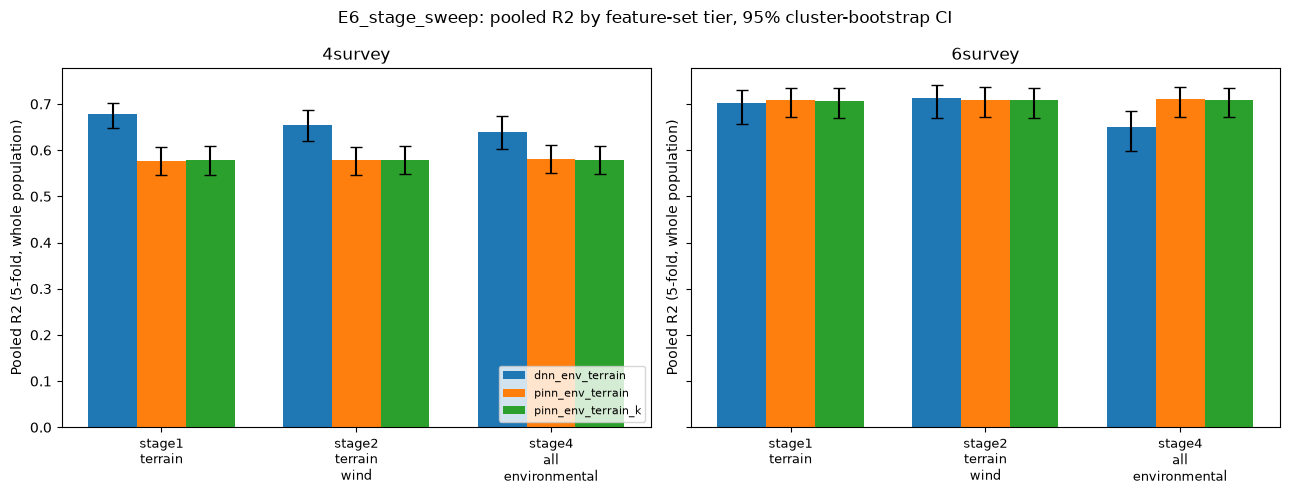

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
x = np.arange(len(E6_TIERS))
width = 0.25

for ax, cohort in zip(axes, E6_COHORTS):
    for i, model in enumerate(E6_MODELS):
        subset = e6_results_df[(e6_results_df["cohort"] == cohort) & (e6_results_df["model"] == model)]
        subset = subset.set_index("tier").reindex(E6_TIERS)
        r2 = subset["pooled_r2"].values
        err_low = r2 - subset["ci_low"].values
        err_high = subset["ci_high"].values - r2
        ax.bar(x + (i - 1) * width, r2, width, yerr=[err_low, err_high], capsize=4, label=model)
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace("_", "\n") for t in E6_TIERS], fontsize=9)
    ax.set_title(cohort)
    ax.set_ylabel("Pooled R2 (5-fold, whole population)")
    ax.axhline(0, color="black", linewidth=0.6)

axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("E6_stage_sweep: pooled R2 by feature-set tier, 95% cluster-bootstrap CI")
plt.tight_layout()
plt.show()

**Findings (2026-08-07)**:

- **`dnn_env_terrain` is clearly hurt by the widest tier.** On 4survey, R2 drops monotonically as
  the tier widens (stage1 -> stage2 -> stage4). On 6survey the drop is sharper: stage1/stage2 both
  score ~0.70-0.71, but stage4 falls to ~0.65 -- a gap whose CI only barely reaches the other
  tiers' CI floors. This is exactly the degradation a VIF-driven multicollinearity concern would
  predict for a plain DNN with no other regularizing structure.
- **Both PINN variants are essentially flat across tiers** -- moving by roughly 0.001-0.004 R2
  either way, well inside each tier's own CI width. The physics constraint appears to make the
  network far less sensitive to which environmental tier it's given, unlike the plain DNN.
- **`stage4_all_environmental` is never the best tier for any model/cohort** in this sweep, and is
  clearly the worst choice for `dnn_env_terrain` specifically. `stage1_terrain` and
  `stage2_terrain_wind` are statistically indistinguishable from each other for every model/cohort
  (their CIs overlap heavily) -- either is a defensible default; `stage4_all_environmental` is not.
- **Conclusion: the statistical screen and the empirical result partially disagree.** More columns
  surviving dedup (stage4 has the most) does not translate into better downstream accuracy -- if
  anything the opposite, for the model family (`dnn_env_terrain`) most exposed to unregularized
  collinearity. `stage1_terrain`/`stage2_terrain_wind` are the recommended defaults going forward,
  not `stage4_all_environmental`.
- **`stage3_terrain_wind_plus` remains untested** -- not part of `E6_stage_sweep`. Given
  stage1/stage2 already look sufficient, this is a low-priority follow-up, not an urgent gap.

See `documentation/experiment_log.md`'s 2026-08-07 entry for the full E6/E7/E8 writeup.